4장 다층 퍼셉트론

In [ ]:
# 예제 4.1 다층 퍼셉트론 XOR 연산

# 셋업
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.initializers import RandomNormal
import numpy as np
import matplotlib.pyplot as plt

# 학습 데이터 준비
x_train = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])   # 입력 데이터
y_train = np.array([[0], [1], [1], [0]])   # 레이블(정답)

In [ ]:
# 모델 생성
inputs = Input(shape=(2,))   # 입력 특징 2개
x = Dense(2, kernel_initializer=RandomNormal(seed=7),   # 은닉층 뉴런 2개
          activation="sigmoid")(inputs)   # sigmoid 함수 사용
outputs =  Dense(1,   # 출력층 뉴런 1개
           kernel_initializer=RandomNormal(seed=7),
           activation="sigmoid")(x)   # sigmoid 함수 사용

model = Model(inputs, outputs)

In [ ]:
# 모델 컴파일
model.compile(optimizer="adam", loss="mse")

In [ ]:
# 모델 학습
history = model.fit(x_train, y_train, epochs=10000, verbose=0)

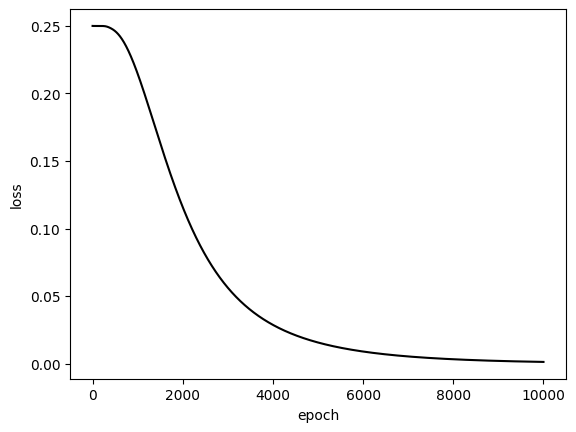

In [ ]:
# 학습 결과 시각화
epochs = range(1, len(history.history['loss']) + 1)

plt.plot(epochs, history.history['loss'], color='black')
plt.xlabel('epoch')
plt.ylabel('loss')

plt.show()

In [ ]:
# 학습 후 은닉층 가중치와 바이어스 확인
weights, biases = model.layers[1].get_weights()

print(f"weights: {weights.round(1)} \nbias: {biases.round(1)}")

weights: [[-6.7 -5.1]
 [-6.8 -5.1]] 
bias: [3.1 7.7]


In [ ]:
# 학습 후 출력층 가중치와 바이어스 확인
weights, bias = model.layers[2].get_weights()

print(f"weights: {weights.round(1)} \nbias: {bias.round(1)}")

weights: [[-7.6]
 [ 8. ]] 
bias: [-4.]


In [ ]:
# 모델 예측
x = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])   # 입력 패턴

threshold = 0.5   # 임계치 0.5

y_pred = (model.predict(x) >= threshold).astype(int).ravel()

for i in range(4):
    print(f"x: {x[i]}   y: {y_pred[i]}")   # 예측 결과 확인

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
x: [0 0]   y: 0
x: [0 1]   y: 1
x: [1 0]   y: 1
x: [1 1]   y: 0


In [ ]:
# 예제 4.2 MLP MNIST 분류

#셋업
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# 데이터셋 준비
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(x_train.shape, y_train.shape)  # 학습 데이터 shape 확인
print(x_test.shape, y_test.shape)    # 테스트 데이터 shape 확인

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


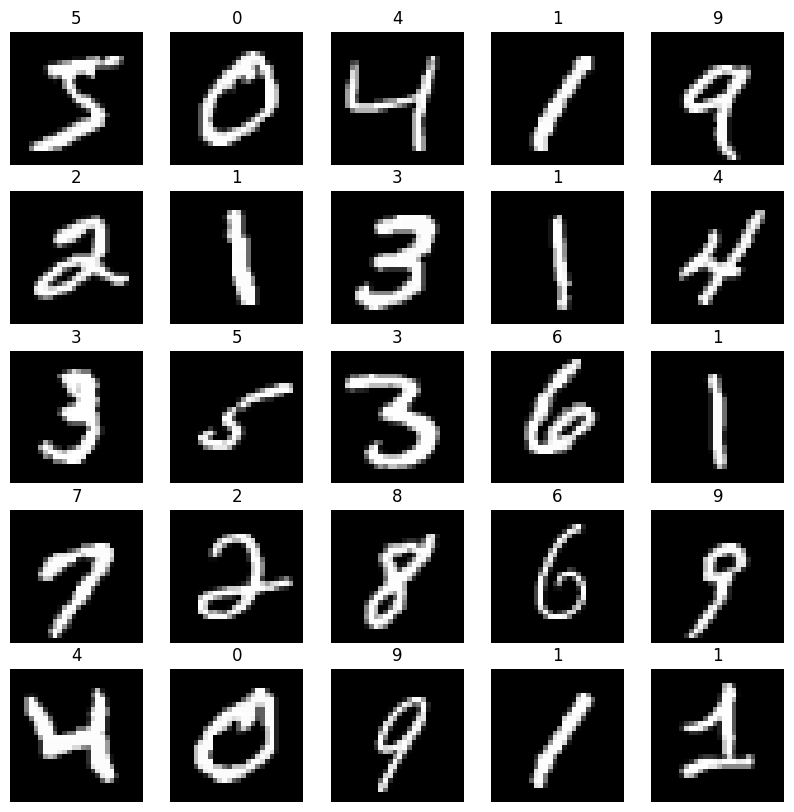

In [ ]:
# 학습 데이터 시각화
plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(y_train[i])   # 레이블
    plt.axis("off")

plt.show()

In [ ]:
# 데이터 정규화
x_train = x_train / 255   # 최소값 0, 최대값 255
x_test = x_test / 255

In [ ]:
# 학습 데이터/검증 데이터 분할
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train, y_train,
    test_size=0.2,   # 분할 비율 0.2
    random_state=77)

print(x_train.shape, y_train.shape)   # 학습 데이터 shape 확인
print(x_valid.shape, y_valid.shape)   # 검증 데이터 shape 확인

(48000, 28, 28) (48000,)
(12000, 28, 28) (12000,)


In [ ]:
# 모델 생성
inputs = Input(shape=(28, 28))   # 입력 특징 28x28
x = Flatten()(inputs)   # 2차원 이미지를 벡터로 변환
x = Dense(128, kernel_initializer=RandomNormal(seed=77),   # 은닉층1 뉴런 128개
          activation="relu", name="hidden_layer1")(x)
x = Dense(64, kernel_initializer=RandomNormal(seed=77),    # 은닉층2 뉴런 64개
          activation="relu", name="hidden_layer2")(x)
outputs = Dense(10, kernel_initializer=RandomNormal(seed=77),   # 출력층 뉴런 10개
          activation="softmax", name="output_layer")(x)

model = Model(inputs, outputs)

In [ ]:
# 모델 컴파일
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])   # 성능 평가 지표로 정확도 사용

In [ ]:
# 모델 학습
history = model.fit(x_train, y_train, epochs=5,
                    validation_data=(x_valid, y_valid))   # 성능 검증용

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8336 - loss: 0.5902 - val_accuracy: 0.9514 - val_loss: 0.1626
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9597 - loss: 0.1371 - val_accuracy: 0.9597 - val_loss: 0.1268
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9719 - loss: 0.0905 - val_accuracy: 0.9635 - val_loss: 0.1149
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9813 - loss: 0.0639 - val_accuracy: 0.9716 - val_loss: 0.0908
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9856 - loss: 0.0475 - val_accuracy: 0.9698 - val_loss: 0.0995


In [ ]:
# 모델 평가
model.evaluate(x_test, y_test)   # 테스트 데이터로 성능 평가

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9674 - loss: 0.1045


[0.09140529483556747, 0.97079998254776]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


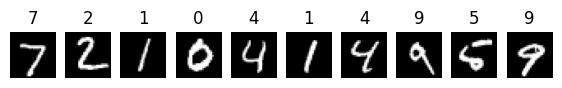


 label: [7 2 1 0 4 1 4 9 5 9]


In [ ]:
# 모델 예측 결과
x = x_test[:10]
y_pred = np.argmax(model.predict(x), axis=1)

plt.figure(figsize=(7, 7))

for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(y_pred[i])
    plt.axis("off")

plt.show()

print(f"\n label: {y_test[:10]}")

In [1]:
# 예제 4.3  MLP 보스턴 주택 가격 예측

# 셋업
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.datasets import boston_housing
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터셋 준비
(x_train, y_train), (x_test, y_test) = boston_housing.load_data()

print(x_train.shape, y_train.shape)   # 학습 데이터 shape
print(x_test.shape, y_test.shape)     # 테스트 데이터 shape

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(404, 13) (404,)
(102, 13) (102,)


In [2]:
# 판다스의 데이터 프레임으로 변환
columns = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", # 컬럼명
           "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"]

x_df = pd.DataFrame(x_train, columns=columns)
y_df = pd.DataFrame(y_train, columns=["MEDV"])

train_df = pd.concat([x_df, y_df], axis=1)

In [ ]:
# 상위 데이터 확인
train_df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,1.23247,0.0,8.14,0.0,0.538,6.142,91.7,3.9769,4.0,307.0,21.0,396.90,18.72,15.2
1,0.02177,82.5,2.03,0.0,0.415,7.610,15.7,6.2700,2.0,348.0,14.7,395.38,3.11,42.3
2,4.89822,0.0,18.10,0.0,0.631,4.970,100.0,1.3325,24.0,666.0,20.2,375.52,3.26,50.0
3,0.03961,0.0,5.19,0.0,0.515,6.037,34.5,5.9853,5.0,224.0,20.2,396.90,8.01,21.1
4,3.69311,0.0,18.10,0.0,0.713,6.376,88.4,2.5671,24.0,666.0,20.2,391.43,14.65,17.7


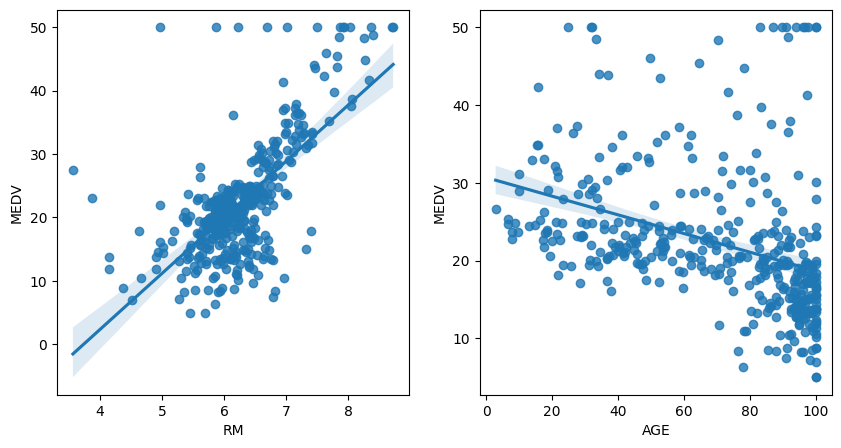

In [ ]:
# 데이터 시각화(선형 회귀)
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
features = ["RM", "AGE"]

for i, feature in enumerate(features):
    sns.regplot(x=feature, y="MEDV", data=train_df, ax=axs[i])

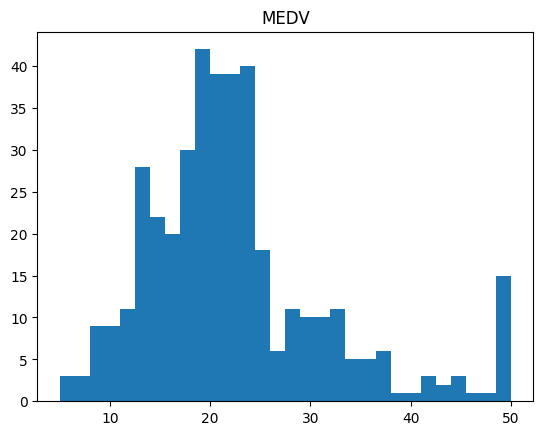

In [ ]:
# 데이터 시각화(히스토그램)
plt.hist(train_df["MEDV"], bins=30)   # 구간 30개
plt.title("MEDV")

plt.show()

In [ ]:
# 학습 데이터 정보 확인
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404 entries, 0 to 403
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     404 non-null    float64
 1   ZN       404 non-null    float64
 2   INDUS    404 non-null    float64
 3   CHAS     404 non-null    float64
 4   NOX      404 non-null    float64
 5   RM       404 non-null    float64
 6   AGE      404 non-null    float64
 7   DIS      404 non-null    float64
 8   RAD      404 non-null    float64
 9   TAX      404 non-null    float64
 10  PTRATIO  404 non-null    float64
 11  B        404 non-null    float64
 12  LSTAT    404 non-null    float64
 13  MEDV     404 non-null    float64
dtypes: float64(14)
memory usage: 44.3 KB


In [3]:
# 학습 데이터 통계 확인
train_df.describe().round(2)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,404.00,404.00,404.00,404.00,404.00,404.00,404.00,404.00,404.00,404.00,404.00,404.00,404.00,404.00
mean,3.75,11.48,11.10,0.06,0.56,6.27,69.01,3.74,9.44,405.90,18.48,354.78,12.74,22.40
std,9.24,23.77,6.81,0.24,0.12,0.71,27.94,2.03,8.70,166.37,2.20,94.11,7.25,9.21
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,188.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.13,0.00,0.45,5.87,45.48,2.08,4.00,279.00,17.23,374.67,6.89,16.68
50%,0.27,0.00,9.69,0.00,0.54,6.20,78.50,3.14,5.00,330.00,19.10,391.25,11.40,20.75
75%,3.67,12.50,18.10,0.00,0.63,6.61,94.10,5.12,24.00,666.00,20.20,396.16,17.09,24.80
max,88.98,100.00,27.74,1.00,0.87,8.72,100.00,10.71,24.00,711.00,22.00,396.90,37.97,50.00


In [ ]:
# 데이터 정규화
mean = np.mean(x_train, axis=0)
std = np.std(x_train, axis=0)

x_train = (x_train - mean) / std
x_test = (x_test - mean) / std

In [ ]:
# 학습 데이터/검증 데이터 분할
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train, y_train,
    test_size=0.2,   # 분할 비율 0.2
    random_state=77)

In [ ]:
# 모델 생성
inputs = Input(shape=(13, ))    # 입력 특징 13개
x = Dense(64,   # 은닉층1 뉴런 64개
          activation="relu",
          kernel_initializer=RandomNormal(seed=77))(inputs)
x = Dense(32,   # 은닉층2 뉴런 32개
          activation="relu",
          kernel_initializer=RandomNormal(seed=77))(x)
outputs = Dense(1,   # 출력층 뉴런 1개(활성화 함수 사용하지 않음)
                kernel_initializer=RandomNormal(seed=77))(x)

model = Model(inputs, outputs)

In [ ]:
# 모델 컴파일
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [ ]:
# 모델 학습
history = model.fit(x_train, y_train,
                    epochs=200, verbose=0,
                    validation_data=(x_valid, y_valid))

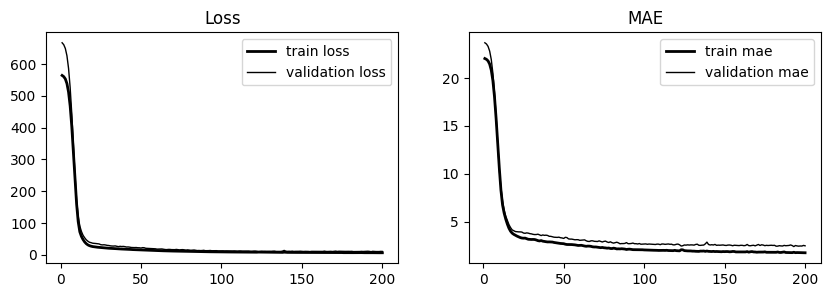

In [ ]:
# 학습 결과 시각화
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(history.history["loss"]) + 1),
         history.history["loss"], label="train loss",
         color="black", linewidth=2)
plt.plot(range(1, len(history.history["val_loss"]) + 1),
         history.history["val_loss"], label="validation loss",
         color="black", linewidth=1)
plt.title("Loss")
plt.legend(loc="best")

plt.subplot(1, 2, 2)
plt.plot(range(1, len(history.history["mae"]) + 1),
         history.history["mae"], label="train mae",
         color="black", linewidth=2)
plt.plot(range(1, len(history.history["val_mae"]) + 1),
         history.history["val_mae"], label="validation mae",
         color="black", linewidth=1)
plt.title("MAE")
plt.legend(loc="best")

plt.show()

In [ ]:
# 모델 평가
model.evaluate(x_test, y_test)   # 테스트 데이터로 성능 평가

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 13.2915 - mae: 2.5442


[17.402877807617188, 2.750988006591797]

In [ ]:
# 모델 예측
y_pred = model.predict(x_test[:5])

print(y_test[:5], "\n")
print(y_pred.reshape(-1).round(2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
[ 7.2 18.8 19.  27.  22.2] 

[ 8.66 18.49 21.49 32.82 24.54]


In [ ]:
# 예제 4.3 그레디언트 계산

import tensorflow as tf

x = tf.Variable(3.)

with tf.GradientTape() as tape:   # 자동 미분 수행
    y = x ** 2
    z = 2 * y + 3

grad_z_of_x = tape.gradient(z, x)   # x에 대한 z의 그레디언트 계산

print(grad_z_of_x)

tf.Tensor(12.0, shape=(), dtype=float32)
